# Solutions

## Runge-Kutta orbit integrations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

In [2]:
def derivs_orbit(t, x):
    # circular orbit
    rr = (x[0]**2 + x[1]**2)**0.5
    vxdot = -x[0]/rr**3
    vydot = -x[1]/rr**3
    xdot = x[2]
    ydot = x[3]
    return np.array((xdot,ydot,vxdot,vydot))

In [3]:
# define our integrators:
# note that we are going to use the first array entry to store 
# the initial condition, so we use an array of length nsteps+1

def euler(nsteps, dt, x0, derivs):
    x = np.zeros((nsteps+1,len(x0)))
    x[0] = x0
    for i in range(1,nsteps+1):    
        f = derivs((i-1)*dt, x[i-1])
        x[i] = x[i-1] + f*dt
    return x

def midpoint(nsteps, dt, x0, derivs):
    x = np.zeros((nsteps+1,len(x0)))
    x[0] = x0
    for i in range(1,nsteps+1):    
        f = derivs((i-1)*dt, x[i-1])
        f1 = derivs((i-1)*dt + dt/2, x[i-1] + f*dt/2)
        x[i] = x[i-1] + f1*dt        
    return x

def rk4(nsteps, dt, x0, derivs):
    x = np.zeros((nsteps+1,len(x0)))
    x[0] = x0
    for i in range(1,nsteps+1):    
        f = derivs((i-1)*dt, x[i-1])
        f1 = derivs((i-1)*dt + dt/2, x[i-1] + f*dt/2)
        f2 = derivs((i-1)*dt + dt/2, x[i-1] + f1*dt/2)
        f3 = derivs(i*dt, x[i-1] + f2*dt)
        x[i] = x[i-1] + dt*(f + 2*f1 + 2*f2 + f3)/6
    return x

nsteps = 10, err1 = 2.29104, err2 = -0.919185, err4 = 0.104254
nsteps = 100, err1 = -1.61902, err2 = -0.0151868, err4 = 3.0433e-06
nsteps = 1000, err1 = -0.358194, err2 = -0.000145595, err4 = 2.32459e-10
nsteps = 10000, err1 = -0.0371252, err2 = -1.44788e-06, err4 = 2.31103e-14
scipy gives  0.00015649600355535642  with 140 evaluations


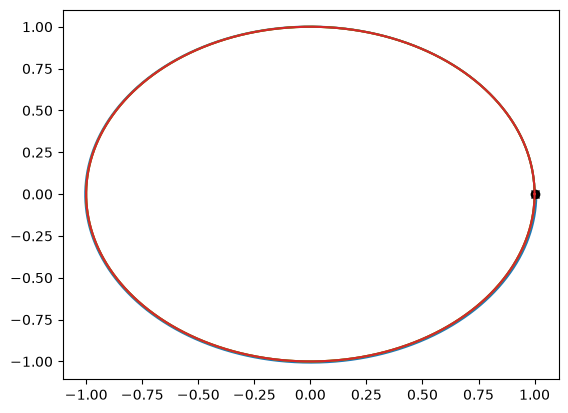

In [4]:
# Compute the orbit with different numbers of steps and methods to compare

for nsteps in np.array((10,100,1000,10000)):

    dt = 2 * np.pi / nsteps
    t = np.arange(nsteps+1)*dt
    x_start = np.array((1,0,0,1))
    x1 = euler(nsteps, dt, x_start, derivs_orbit)
    x2 = midpoint(nsteps, dt, x_start, derivs_orbit)
    x4 = rk4(nsteps, dt, x_start, derivs_orbit)

    print("nsteps = %d, err1 = %lg, err2 = %lg, err4 = %lg" % (nsteps, x1[-1,1], x2[-1,1], x4[-1,1]))
    
plt.plot(x1[:,0], x1[:,1])
plt.plot(x2[:,0], x2[:,1])
plt.plot(x4[:,0], x4[:,1])

plt.plot(x4[0,0],x4[0,1],'ko')
plt.plot(x4[-1,0],x4[-1,1],'kx')

result = scipy.integrate.solve_ivp(derivs_orbit, (0.0,2.0*np.pi), x_start, t_eval=t, atol=1e-6, rtol=1e-6)

x,y, vx, vy = result.y

print('scipy gives ', y[-1], ' with %d evaluations' % (result.nfev,))
plt.plot(x,y)
plt.show()

nsteps = 10, err4 = 0.104254
nsteps = 12, err4 = 0.0430479
nsteps = 15, err4 = 0.0148614
nsteps = 19, err4 = 0.00490612
nsteps = 25, err4 = 0.00138201
nsteps = 31, err4 = 0.000518955
nsteps = 39, err4 = 0.000184788
nsteps = 50, err4 = 6.13209e-05
nsteps = 63, err4 = 2.22674e-05
nsteps = 79, err4 = 8.35403e-06
nsteps = 100, err4 = 3.0433e-06
nsteps = 125, err4 = 1.18144e-06
nsteps = 158, err4 = 4.41478e-07
nsteps = 199, err4 = 1.68802e-07
nsteps = 251, err4 = 6.45979e-08
nsteps = 316, err4 = 2.50556e-08
nsteps = 398, err4 = 9.74852e-09
nsteps = 501, err4 = 3.81677e-09
nsteps = 630, err4 = 1.50564e-09
nsteps = 794, err4 = 5.90161e-10
nsteps = 1000, err4 = 2.32459e-10
nsteps = 1258, err4 = 9.2183e-11
nsteps = 1584, err4 = 3.64872e-11
nsteps = 1995, err4 = 1.43891e-11
nsteps = 2511, err4 = 5.73532e-12
nsteps = 3162, err4 = 2.29209e-12
nsteps = 3981, err4 = 8.93397e-13
nsteps = 5011, err4 = 2.91551e-13
nsteps = 6309, err4 = 1.18451e-13
nsteps = 7943, err4 = 1.10602e-13
nsteps = 10000, err4 

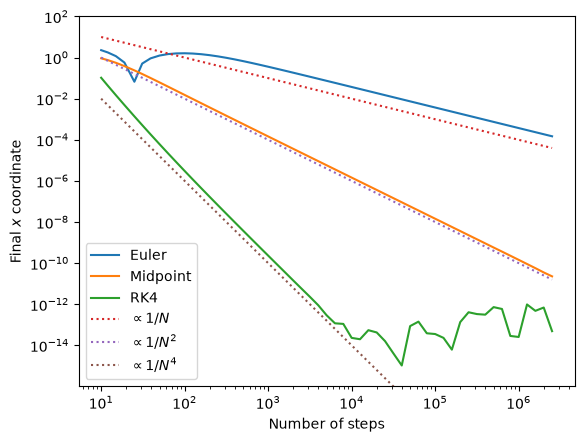

In [5]:
# Calculate the scaling with N

nvals = np.array([])
evals1 = np.array([])
evals2 = np.array([])
evals4 = np.array([])

for n in np.arange(1,6.5,0.1):

    nsteps = int(10**n)
    dt = 2 * np.pi / nsteps
    t = np.arange(nsteps+1)*dt
    x_start = np.array((1,0,0,1))
    x1 = euler(nsteps, dt, x_start, derivs_orbit)
    x2 = midpoint(nsteps, dt, x_start, derivs_orbit)
    x4 = rk4(nsteps, dt, x_start, derivs_orbit)

    print("nsteps = %d, err4 = %lg" % (nsteps, x4[-1,1]))
    nvals = np.append(nvals, nsteps)
    evals1 = np.append(evals1, abs(x1[-1,1]))
    evals2 = np.append(evals2, abs(x2[-1,1]))
    evals4 = np.append(evals4, abs(x4[-1,1]))

plt.plot(nvals, evals1, label='Euler')
plt.plot(nvals, evals2, label='Midpoint')
plt.plot(nvals, evals4, label='RK4')

plt.ylim((np.min(evals4)*0.1,100))

plt.plot(nvals, 100/nvals, ":", label = r'$\propto 1/N$')
plt.plot(nvals, 100/nvals**2, ":", label = r'$\propto 1/N^2$')
plt.plot(nvals, 100/nvals**4, ":", label = r'$\propto 1/N^4$')

plt.legend()
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'Final $x$ coordinate')
plt.xlabel(r'Number of steps')
plt.show()

The curves have the linear, quadratic and 4th order scaling we were expecting. The "dip" in the blue curve is a zero-crossing, which appears as a dip when we take the absolute value. Note also that the RK4 integrator is so good that we hit roundoff after $10^4$ steps.

## Implicit methods, linear system

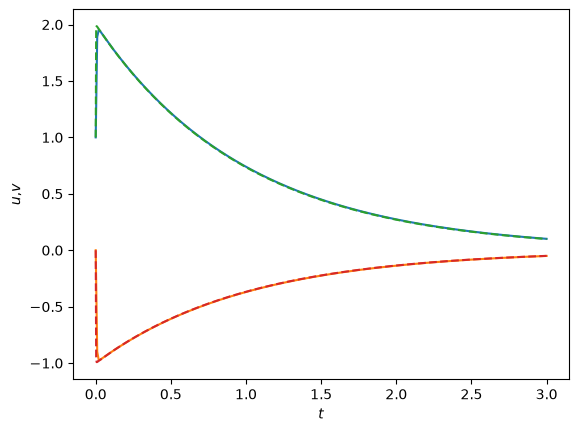

In [6]:
# The equations are linear with constant coefficients, so don't need
# to do a Newton solve
# We just need to specify the matrix of coefficients
C = np.array([[-998,-1998],[999,1999]])

h = 1e-2
t_end = 3
nsteps = int(t_end/h)

# length nsteps+1 because we also store the initial condition
x = np.zeros((nsteps+1,2))

# Explicit update
#A = np.identity(2) - h*C
# Implicit update
A = np.linalg.inv(np.identity(2) + h*C)

# Initial conditions
x[0,0] = 1
x[0,1] = 0

for i in range(1,nsteps+1):
    x[i] = A@x[i-1]
    
t = h * np.arange(nsteps+1)

plt.plot(t,x[:,0])
plt.plot(t,x[:,1])

# Plot the analytic solutions for comparison
t_anal = np.linspace(t[0], t[-1], 1000)
plt.plot(t_anal, 2*np.exp(-t_anal)-np.exp(-1000*t_anal),"--")
plt.plot(t_anal, -np.exp(-t_anal)+np.exp(-1000*t_anal),"--")

plt.xlabel(r'$t$')
plt.ylabel(r'$u$,$v$')

plt.show()

Running this with the explicit method, we can see instability for timesteps $\gtrsim 10^{-3}$. The implicit method on the other hand can run stably with larger timesteps. In the example above, with timestep $10^{-2}$, we can see deviations from the analytic model (dashed lines) at early times during the initial fast evolution, but the longer time evolution is accurately followed.

## Implicit method, finite amplitude pendulum

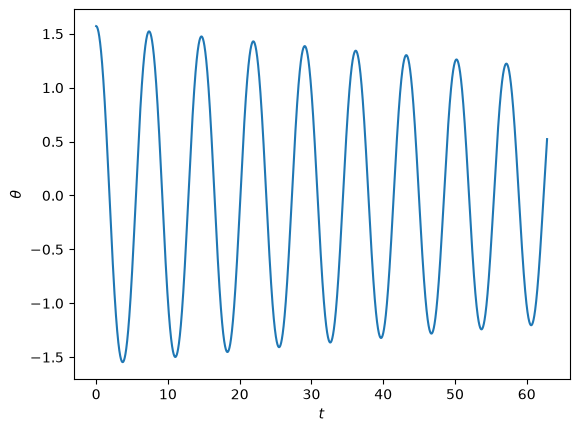

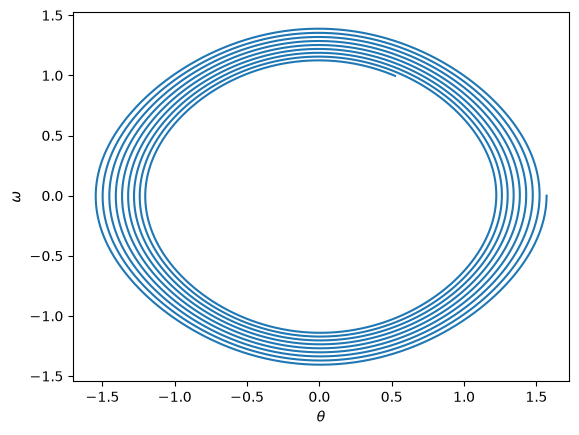

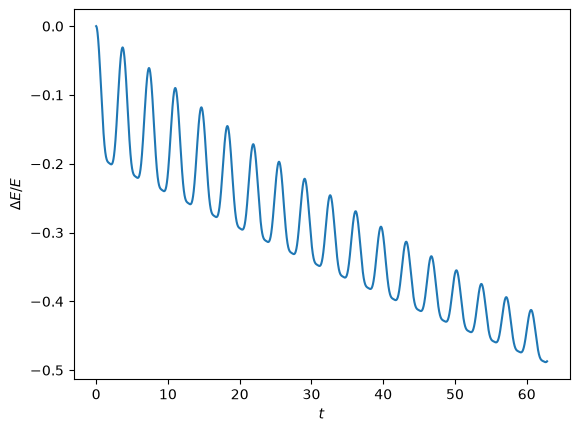

In [7]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.01
t_end = 2*np.pi * 10
nsteps = int(t_end / h)

# Initial conditions
theta = np.zeros(nsteps+1)
omega = np.zeros(nsteps+1)

theta[0] = np.pi/2    # initial angle (radians)
omega[0] = 0.0

# Newton parameters
tol = 1e-3
max_iter = 10

for n in range(nsteps):
    
    # Initial guess for theta_{n+1}, omega_{n+1}
    # Use the previous timestep as the initial guess
    x = np.array([theta[n], omega[n]])

    # Newton iterations
    for k in range(max_iter):

        th, om = x
 
        F = np.array([th - theta[n] - h * om, om - omega[n] + h * np.sin(th)])
        J = np.array([[1.0,  -h],[h * np.cos(th),  1.0]])

        # solve for delta y and update
        delta = np.linalg.solve(J, -F)
        x += delta

        #print('iteration %d, delta = %lg' % (k, np.linalg.norm(delta)))
        
        # Check convergence
        if np.linalg.norm(delta) < tol:
            break

    # Store converged solution
    theta[n+1] = x[0]
    omega[n+1] = x[1]

    # Explicit
    # (uncomment to use the explicit update instead of the implicit one)
    #theta[n+1] = theta[n] + h*omega[n]
    #omega[n+1] = omega[n] - h*np.sin(theta[n])

# Plot
t = np.linspace(0, t_end, nsteps+1)

plt.plot(t, theta)
plt.xlabel(r'$t$')
plt.ylabel(r'$\theta$')
plt.show()

plt.figure()
plt.plot(theta,omega)
plt.ylabel(r'$\omega$')
plt.xlabel(r'$\theta$')
plt.show()

plt.figure()
E = theta**2 + omega**2
plt.plot(t, (E-E[0])/E[0])
plt.ylabel(r'$\Delta E/E$')
plt.xlabel(r'$t$')
plt.show()

Comparing the implicit and explicit updates, we see that the oscillation amplitude grows with the explicit update but decays with implicit. The Newton method usually convergences in one or two iterations for small $h$. This amplitude behaviour motivates looking for methods that will automatically conserve energy -- we'll discuss this next time.

## Symplectic integrator exercise

In [8]:
import sympy.matrices
from sympy import init_session
# get nice printing of matrices
init_session(quiet = True)

The first thing we need to do is write down each scheme as a set of matrices. We're doing the harmonic oscillator, so we'll use $a = -x$. 

**Euler**. The update is

$$x_{n+1} = x_n + h v_n$$
$$v_{n+1} = v_n -h x_n$$

which we can write by inspection as
$$\begin{pmatrix}x_{n+1} \\ v_{n+1}  \end{pmatrix} = \begin{pmatrix} 1 & h \\ -h & 1 \end{pmatrix} \begin{pmatrix}x_n \\ v_n  \end{pmatrix}.$$

**Midpoint**. The update is:

$$x_{n+1/2} = x_n + v_n {h\over 2}, \hspace{1cm} v_{n+1/2} = v_n - x_n {h\over 2}$$
$$x_{n+1} = x_n + h v_{n+1/2}, \hspace{1cm} v_{n+1} = v_n - h x_{n+1/2}.$$

Combine these to get a single step going from $n$ to $n=1$:
$$x_{n+1} = x_n + h v_n - {h^2\over 2} x_n$$
$$v_{n+1} = v_n - h x_n - {h^2\over 2} v_n,$$

or
$$\begin{pmatrix}x_{n+1} \\ v_{n+1}  \end{pmatrix} =  \begin{pmatrix} 1-{h^2\over 2} & h \\ -h & 1-{h^2\over 2} \end{pmatrix}\begin{pmatrix}x_n \\ v_n  \end{pmatrix}.$$


**Euler-Cromer**. The update is 

$$v_{n+1} = v_n + a_n \Delta t$$
$$x_{n+1} = x_n + v_{n+1} \Delta t$$

which we can model as two steps:

$$\begin{pmatrix}x_{n+1} \\ v_{n+1}  \end{pmatrix}=\begin{pmatrix} 1 & h \\ 0 & 1 \end{pmatrix}\begin{pmatrix} 1 & 0 \\ -h & 1 \end{pmatrix}\begin{pmatrix}x_n \\ v_n  \end{pmatrix}.$$

**Leapfrog**. In this case, there are three steps:

$$v_{n+1/2} = v_n + a_n {h\over 2}$$
$$x_{n+1} = x_n + v_{n+1/2}h$$
$$v_{n+1} = v_{n+1/2} + a_{n+1} {h\over 2}.$$

The first and third steps are actually the same operator, so overall we have:

$$\begin{pmatrix}x_{n+1} \\ v_{n+1}  \end{pmatrix}=\begin{pmatrix} 1 & 0 \\ -{h\over 2} & 1 \end{pmatrix}\begin{pmatrix} 1 & h \\ 0 & 1 \end{pmatrix}\begin{pmatrix} 1 & 0 \\ -{h\over 2} & 1 \end{pmatrix}\begin{pmatrix}x_n \\ v_n  \end{pmatrix}.$$

In [9]:
# Euler
def J_euler(h):
    return sympy.matrices.Matrix([[1,h],[-h,1]])

def J_midpoint(h):
    return sympy.matrices.Matrix([[1-h*h/2,h],[-h,1-h*h/2]])

def J_eulercromer(h):
    a = sympy.matrices.Matrix([[1,h],[0,1]])
    b = sympy.matrices.Matrix([[1,0],[-h,1]])
    return a*b

def J_leapfrog(h):
    a = sympy.matrices.Matrix([[1,0],[-h/2,1]])
    b = sympy.matrices.Matrix([[1,h],[0,1]])
    return a*b*a

# declare symbols
h = sympy.Symbol('h')
x = sympy.Symbol('x')
v = sympy.Symbol('v')
xv = sympy.matrices.Matrix([x, v])

integrators = (J_euler, J_midpoint, J_eulercromer, J_leapfrog)

for J in integrators:
    print('----------------------\n', J.__name__, '\n----------------------')
    print("Jacobian = ")
    pprint(sympy.simplify(J(h)))    
    print("\nDeterminant = ", J(h).det())
    print("\nForwards then backwards step = ")
    pprint(sympy.simplify(J(-h)*J(h)))
    print("\nInverse = ")
    pprint(sympy.simplify(J(h).inv()))
    print('\nE_n+1 = ', sympy.simplify(xv.T * J(h).T * J(h) * xv)[0])
    if J is J_eulercromer:
        print("Check conserved energy:")
        x1 = J(h)*xv
        pprint(sympy.simplify( (x1[0]**2+x1[1]**2)/2 - h*x1[0]*x1[1]/2 ))
    if J is J_leapfrog:
        print("Check conserved energy:")
        x1 = J(h)*xv
        pprint(sympy.simplify( (x1[0]**2+x1[1]**2)/2 - (h**2/8)*x1[0]**2 ))

----------------------
 J_euler 
----------------------
Jacobian = 
⎡1   h⎤
⎢     ⎥
⎣-h  1⎦

Determinant =  h**2 + 1

Forwards then backwards step = 
⎡ 2            ⎤
⎢h  + 1    0   ⎥
⎢              ⎥
⎢         2    ⎥
⎣  0     h  + 1⎦

Inverse = 
⎡  1      -h   ⎤
⎢──────  ──────⎥
⎢ 2       2    ⎥
⎢h  + 1  h  + 1⎥
⎢              ⎥
⎢  h       1   ⎥
⎢──────  ──────⎥
⎢ 2       2    ⎥
⎣h  + 1  h  + 1⎦

E_n+1 =  h**2*v**2 + h**2*x**2 + v**2 + x**2
----------------------
 J_midpoint 
----------------------
Jacobian = 
⎡     2        ⎤
⎢    h         ⎥
⎢1 - ──    h   ⎥
⎢    2         ⎥
⎢              ⎥
⎢             2⎥
⎢            h ⎥
⎢  -h    1 - ──⎥
⎣            2 ⎦

Determinant =  h**4/4 + 1

Forwards then backwards step = 
⎡ 4            ⎤
⎢h             ⎥
⎢── + 1    0   ⎥
⎢4             ⎥
⎢              ⎥
⎢         4    ⎥
⎢        h     ⎥
⎢  0     ── + 1⎥
⎣        4     ⎦

Inverse = 
⎡  ⎛     2⎞            ⎤
⎢2⋅⎝2 - h ⎠    -4⋅h    ⎥
⎢──────────    ──────  ⎥
⎢   4           4      ⎥
⎢  h 

The symplectic methods each have their own conserved quantity that is close to the energy, but with a correction term that is either first or second order in $h$ respectively. To confirm this, here is a numerical solution for the harmonic oscillator that compares the different methods.

In [10]:
# First define the various integrators
# they all take an initial position vector x0 and velocity v0
# and return x(t), v(t)

def midpoint(nsteps, dt, x0, v0):
    x = np.zeros(nsteps+1)
    v = np.zeros(nsteps+1)
    x[0] = x0
    v[0] = v0
    for i in range(1, nsteps+1):
        x12 = x[i-1] + v[i-1]*dt/2
        v12 = v[i-1] - x[i-1]*dt/2
        x[i] = x[i-1] + v12*dt
        v[i] = v[i-1] - x12*dt
    return x, v

def euler(nsteps, dt, x0, v0):
    x = np.zeros(nsteps+1)
    v = np.zeros(nsteps+1)
    x[0] = x0
    v[0] = v0
    for i in range(1, nsteps+1):
        v[i] = v[i-1] - x[i-1] * dt
        x[i] = x[i-1] + v[i-1] * dt
    return x, v

def leapfrog(nsteps, dt, x0, v0):
    x = np.zeros(nsteps+1)
    v = np.zeros(nsteps+1)
    x[0] = x0
    v[0] = v0
    for i in range(1, nsteps+1):
        v12 = v[i-1] - x[i-1] * dt/2
        x[i] = x[i-1] + v12 * dt
        v[i] = v12 - x[i] * dt/2
    return x, v

def euler_cromer(nsteps, dt, x0, v0):
    x = np.zeros(nsteps+1)
    v = np.zeros(nsteps+1)
    x[0] = x0
    v[0] = v0
    for i in range(1, nsteps+1):
        v[i] = v[i-1] - x[i-1] * dt
        x[i] = x[i-1] + v[i] * dt
    return x, v

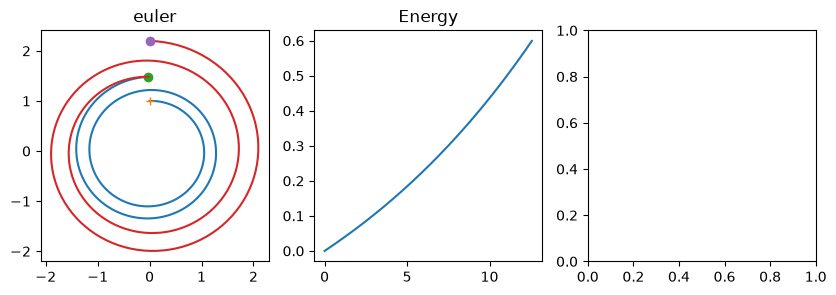

final location (x,v) = (-0.0244634,1.48271), time/2pi=2
final E+0.5=1.59951, max E+0.5=1.59951
After integrating backwards, (x,v) = (-6.93889e-16,2.19902)


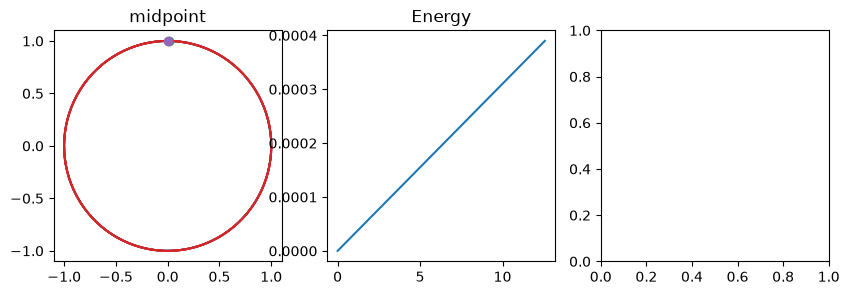

final location (x,v) = (0.00826166,1.00036), time/2pi=2
final E+0.5=1.00039, max E+0.5=1.00039
After integrating backwards, (x,v) = (-5.55112e-16,1.00078)


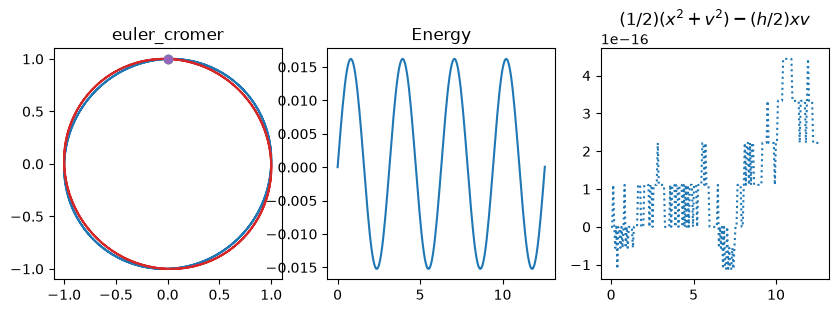

final location (x,v) = (0.00206902,1.00006), time/2pi=2
final E+0.5=1.00007, max E+0.5=1.01621
After integrating backwards, (x,v) = (-2.68974e-07,1.00013)


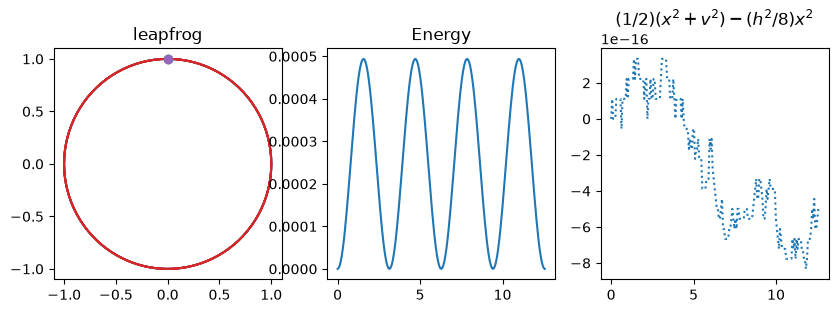

final location (x,v) = (0.00206902,0.999998), time/2pi=2
final E+0.5=1, max E+0.5=1.00049
After integrating backwards, (x,v) = (-1.94289e-16,1)


In [11]:
nsteps = 100   # number of steps per oscillation period
norbits = 2 # number of oscillations to integrate

integrators = (euler, midpoint, euler_cromer, leapfrog)

for integrator in integrators:

    dt = 2*np.pi / nsteps
    t = np.arange(int(nsteps*norbits+1))*dt
    x, v = integrator(int(nsteps*norbits), dt, 0, 1)
    E = 0.5 * (x**2 + v**2)
    
    fig = plt.figure(figsize=(10,3))
    plt.subplot(131)
    plt.plot(x, v)
    plt.plot(x[0], v[0], '+')
    plt.plot(x[-1], v[-1], 'o')
    plt.title(integrator.__name__)

    # now integrate back in time
    x2, v2 = integrator(int(nsteps*norbits), -dt, x[-1], v[-1])
    plt.plot(x2, v2)
    plt.plot(x2[-1], v2[-1], 'o')

    plt.subplot(132)
    plt.plot(t, E-0.5)
    plt.title('Energy')
    
    plt.subplot(133)
    if integrator is euler_cromer:
        plt.plot(t, E - 0.5 * dt * x * v - 0.5,":")
        plt.title(r'$(1/2)(x^2+v^2)-(h/2) xv$')
    if integrator is leapfrog:
        plt.plot(t, E - 0.125 * dt**2 * x**2 - 0.5,":")
        plt.title(r'$(1/2)(x^2+v^2)-(h^2/8) x^2$')

    plt.show()

    print('final location (x,v) = (%lg,%lg), time/2pi=%lg' % (x[-1],v[-1],t[-1]/(2*np.pi)))
    print('final E+0.5=%lg, max E+0.5=%lg' % (E[-1]+0.5,max(abs(E+0.5))))
    print('After integrating backwards, (x,v) = (%lg,%lg)' % (x2[-1],v2[-1]))


And then finally we can check the scalings with $N$:

Calculating leapfrog
Calculating midpoint
Calculating euler_cromer
Calculating euler


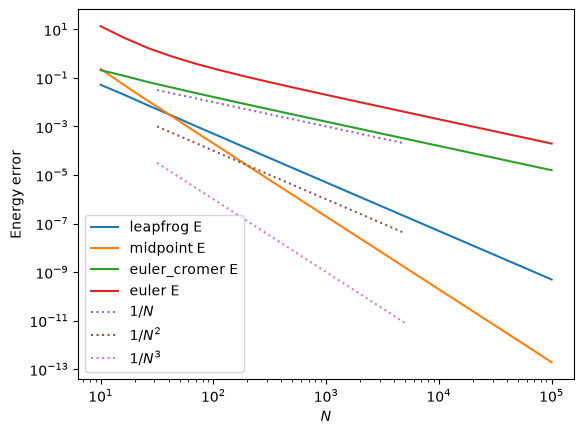

In [12]:
integrators = (euler,euler_cromer, midpoint,leapfrog)

for integrator in integrators[::-1]:
    
    print('Calculating %s' % (integrator.__name__,))
    
    n_vec = 10**np.linspace(1,5,20)
    E_vec = np.zeros_like(n_vec)
    x_vec = np.zeros_like(n_vec)

    norbits = 1
    
    for i, nsteps in enumerate(n_vec):
        dt = 2*np.pi / int(nsteps)
        x, v = integrator(int(nsteps*norbits), dt, 0, 1)
        E = 0.5 * (x**2 + v**2)
        E_vec[i] = max(abs(E-0.5))
        x_vec[i] = np.abs(x[-1])
        
    plt.plot(n_vec, E_vec, label = integrator.__name__+' E')
    #plt.plot(n_vec, x_vec, label = integrator.__name__+ ' x')

n_vec = 10**np.linspace(1.5,3.7,10)
plt.plot(n_vec, 1/n_vec,":", label=r'$1/N$')
plt.plot(n_vec, 1/n_vec**2,":", label=r'$1/N^2$')
plt.plot(n_vec, 1/n_vec**3,":", label=r'$1/N^3$')

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$N$')
plt.ylabel(r'Energy error')
plt.legend()
plt.show()

Note that the midpoint method actually does the best! It scales $\propto N^3$ which is consistent with the analysis above where we found that the local error is $\propto h^4$ so the global error must be $\propto h^3$. 
The symplectic methods are lower order but they have the advantage that the energy is bounded.